# Notebook 6 -- Baseline and Machine-Learning Model Benchmarks

**Goal:** train several regression models and compare them against a naive baseline.

This notebook implements the core ML benchmark:

- Dummy mean baseline
- Ridge regression
- Random Forest
- Extra Trees
- Gradient Boosting
- MLP regressor

In [1]:
# Core scientific stack
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Resolve project root whether the notebook is run from /notebooks or from the repository root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

for folder in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42


def print_section(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

# Notebook-aware figure saving -------------------------------------------------
# Every plot generated in this notebook is saved under reports/figures/.
# The counter prevents overwriting plots produced inside loops.
import re

NOTEBOOK_ID = "06_baseline_and_machine_learning_models"
_FIGURE_SAVE_COUNTER = 1


def _safe_filename(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_") or "figure"


def save_figure(fig, name: str = "figure", dpi: int = 180):
    """Save a matplotlib figure to reports/figures with a notebook-specific name."""
    global _FIGURE_SAVE_COUNTER
    filename = f"{NOTEBOOK_ID}_{_FIGURE_SAVE_COUNTER:02d}_{_safe_filename(name)}.png"
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path.relative_to(PROJECT_ROOT)}")
    _FIGURE_SAVE_COUNTER += 1
    return path


## 6.1 Loading configuration and modeling data

In [2]:
import yaml
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, cross_validate

from nigeria_crop_yield.models.train import make_models, make_preprocessor, split_data

CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

MODELING_CSV = PROCESSED_DIR / "modeling_dataset.csv"
modeling_df = pd.read_csv(MODELING_CSV)

TARGET = config["nbs"].get("target", "yield_kg_ha")
LEAKAGE_COLUMNS = set(config["modeling"].get("leakage_columns", []))
numeric_features = [c for c in config["modeling"].get("numeric_features", []) if c in modeling_df.columns and c not in LEAKAGE_COLUMNS]
categorical_features = [c for c in config["modeling"].get("categorical_features", []) if c in modeling_df.columns and c not in LEAKAGE_COLUMNS]
feature_cols = numeric_features + categorical_features

modeling_df = modeling_df[modeling_df[TARGET].notna()].copy()
print(modeling_df.shape)
print("Features:", feature_cols)
display(modeling_df.head())

(490, 27)
Features: ['households_reporting_000', 'planted_area_ha', 'latitude', 'longitude', 'total_rainfall_mm', 'mean_tmean_c', 'mean_tmax_c', 'mean_tmin_c', 'mean_rh_percent', 'growing_degree_days', 'heat_stress_days', 'crop', 'season', 'zone', 'agroecological_zone']


,season,zone,state,crop,households_reporting_000,planted_area_ha,harvested_area_ha,harvested_quantity_kg,yield_kg_ha,is_aggregate,source_sheet,source_table,geopolitical_zone,agroecological_zone,latitude,longitude,log_planted_area_ha,total_rainfall_mm,mean_tmean_c,mean_tmax_c,mean_tmin_c,mean_rh_percent,mean_wind_speed_m_s,growing_degree_days,heat_stress_days,mean_solar_radiation_kwh_m2_day,total_solar_radiation_kwh_m2
0,major,North Central,Benue,MAIZE,850.39,367795.171270,350398.700331,3.939929e+08,1124.413179,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,7.34,8.74,12.815284,2791.10,25.855397,30.575918,21.825959,75.860397,1.950466,11574.44,2.0,18.280082,13344.46
1,major,North Central,FCT,MAIZE,266.34,153246.079216,123737.798835,1.606178e+08,1298.049753,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,9.08,7.40,11.939807,2791.66,25.271973,31.020178,20.592260,71.285904,1.552260,11148.54,94.0,19.003315,13872.42
2,major,North Central,Kogi,MAIZE,640.86,327793.065371,309235.626289,4.257146e+08,1376.667527,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,7.80,6.74,12.700141,2922.19,25.946644,30.472301,21.926014,77.683192,1.599945,11641.05,2.0,17.665493,12895.81
3,major,North Central,Kwara,MAIZE,398.11,307483.872742,301489.864767,5.002011e+08,1659.097522,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,8.50,4.55,12.636181,3120.12,25.177890,30.194986,21.067233,78.085986,1.852548,11079.86,11.0,18.085219,13202.21
4,major,North Central,Nasarawa,MAIZE,520.48,416547.122485,360177.787028,4.213675e+08,1169.887511,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,8.54,8.32,12.939757,2904.55,26.104479,31.606562,21.643397,71.356986,1.675493,11756.27,113.0,18.834699,13749.33


## 6.2 Creating a grouped train/test split

In [3]:
train_df, test_df = split_data(
    modeling_df,
    target=TARGET,
    test_size=config["modeling"].get("test_size", 0.25),
    random_state=RANDOM_STATE,
    group_col="state",
)

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test, y_test = test_df[feature_cols], test_df[TARGET]

groups_train = train_df["state"]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Train states:", train_df["state"].nunique(), "Test states:", test_df["state"].nunique())

X_train: (368, 15) X_test: (122, 15)
Train states: 27 Test states: 10


## 6.3 Defining preprocessing and candidate models

In [4]:
preprocessor = make_preprocessor(numeric_features, categorical_features)
models = make_models(random_state=RANDOM_STATE)

selected_models = config["modeling"].get("include_models", list(models.keys()))
selected_models = [m for m in selected_models if m in models]

print("Models to benchmark:")
for name in selected_models:
    print(" -", name, "=>", models[name].__class__.__name__)

Models to benchmark:
 - dummy_mean => DummyRegressor
 - ridge => Ridge
 - random_forest => RandomForestRegressor
 - extra_trees => ExtraTreesRegressor
 - gradient_boosting => GradientBoostingRegressor
 - mlp => MLPRegressor


## 6.4 Cross-validation on the training set

I use grouped cross-validation by state when possible. This gives a stricter estimate of generalization to unseen states.

,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
4,gradient_boosting,1045.639817,167.819710,1920.762682,396.813768,0.344524,0.039007
2,random_forest,1093.949712,233.104641,1962.598056,364.947435,0.301784,0.121744
3,extra_trees,1128.492072,321.901171,2070.020012,316.535181,0.177302,0.307993
0,dummy_mean,1704.837407,147.322243,2430.297070,584.540525,-0.032600,0.018405
1,ridge,1606.504956,614.677821,2522.439413,438.798706,-0.350753,0.827183


Saved figure: reports\figures\06_baseline_and_machine_learning_models_01_figure_01.png


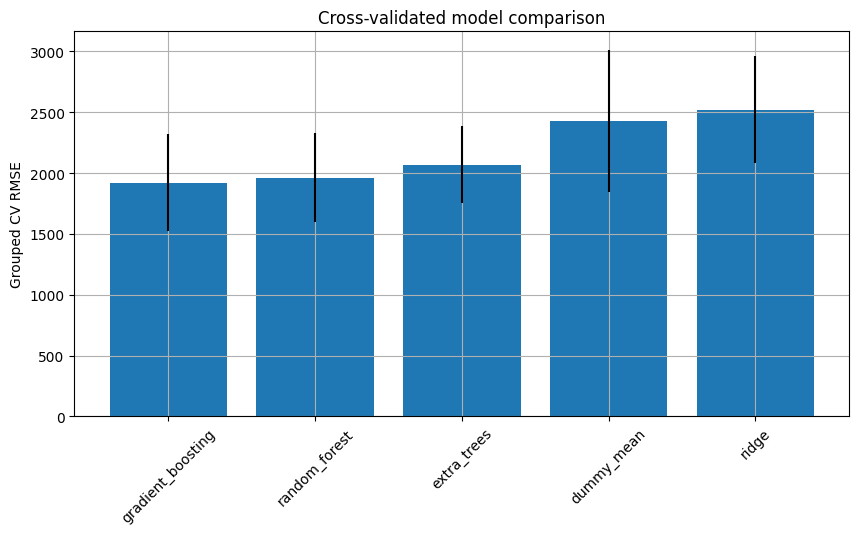

FAST_MODE=True: skipped MLP during cross-validation to keep the notebook quick. It is still evaluated on the hold-out split below.


In [5]:
cv_rows = []
# Keep the notebook runnable on a laptop. Set FAST_MODE=False to include every model in CV.
FAST_MODE = True
cv_model_names = [m for m in selected_models if not (FAST_MODE and m == "mlp")]
n_splits = min(3 if FAST_MODE else 5, train_df["state"].nunique())
cv = GroupKFold(n_splits=n_splits)

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

for name in cv_model_names:
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", models[name])])
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        groups=groups_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score="raise",
    )
    cv_rows.append({
        "model": name,
        "cv_mae_mean": -scores["test_mae"].mean(),
        "cv_mae_std": scores["test_mae"].std(),
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_rmse_std": scores["test_rmse"].std(),
        "cv_r2_mean": scores["test_r2"].mean(),
        "cv_r2_std": scores["test_r2"].std(),
    })

cv_metrics = pd.DataFrame(cv_rows).sort_values("cv_rmse_mean")
display(cv_metrics)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cv_metrics["model"], cv_metrics["cv_rmse_mean"], yerr=cv_metrics["cv_rmse_std"])
ax.set_ylabel("Grouped CV RMSE")
ax.set_title("Cross-validated model comparison")
ax.tick_params(axis="x", rotation=45)
save_figure(fig, "figure_01")
plt.show()

if FAST_MODE and "mlp" in selected_models:
    print("FAST_MODE=True: skipped MLP during cross-validation to keep the notebook quick. It is still evaluated on the hold-out split below.")

## 6.5 Fitting each model and evaluating on the held-out state split

In [6]:
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1))) * 100
    return {"rmse": rmse, "mae": mae, "r2": r2, "mape_percent": mape}

holdout_rows = []
prediction_frames = []
fitted_pipelines = {}

for name in selected_models:
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", models[name])])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    metrics = regression_metrics(y_test, pred)
    holdout_rows.append({"model": name, **metrics})
    fitted_pipelines[name] = pipe

    pred_df = test_df[["state", "zone", "agroecological_zone", "crop", "season", TARGET]].copy()
    pred_df["prediction"] = pred
    pred_df["residual"] = pred_df[TARGET] - pred_df["prediction"]
    pred_df["abs_error"] = pred_df["residual"].abs()
    pred_df["model"] = name
    prediction_frames.append(pred_df)

holdout_metrics = pd.DataFrame(holdout_rows).sort_values("rmse")
predictions = pd.concat(prediction_frames, ignore_index=True)

print_section("Hold-out metrics")
display(holdout_metrics)


Hold-out metrics


,model,rmse,mae,r2,mape_percent
4,gradient_boosting,1338.002682,808.053569,0.595101,52.217455
1,ridge,1407.827288,945.651255,0.551738,63.037315
2,random_forest,1438.374080,801.043891,0.532074,44.690059
5,mlp,1764.041648,1250.293281,0.296197,94.515606
3,extra_trees,1770.972183,915.634509,0.290656,52.413795
0,dummy_mean,2132.642120,1654.816282,-0.028654,129.411026


## 6.6 Saving metrics and predictions generated by this notebook

In [7]:
METRICS_CSV = TABLES_DIR / "model_metrics_notebook06.csv"
PREDICTIONS_CSV = TABLES_DIR / "model_predictions_notebook06.csv"
CV_METRICS_CSV = TABLES_DIR / "cv_metrics_notebook06.csv"

holdout_metrics.to_csv(METRICS_CSV, index=False)
predictions.to_csv(PREDICTIONS_CSV, index=False)
cv_metrics.to_csv(CV_METRICS_CSV, index=False)

print("Saved:", METRICS_CSV)
print("Saved:", PREDICTIONS_CSV)
print("Saved:", CV_METRICS_CSV)

Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\reports\tables\model_metrics_notebook06.csv
Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\reports\tables\model_predictions_notebook06.csv
Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\reports\tables\cv_metrics_notebook06.csv


## 6.7 Actual versus predicted plot for the best model

Saved figure: reports\figures\06_baseline_and_machine_learning_models_02_figure_02.png


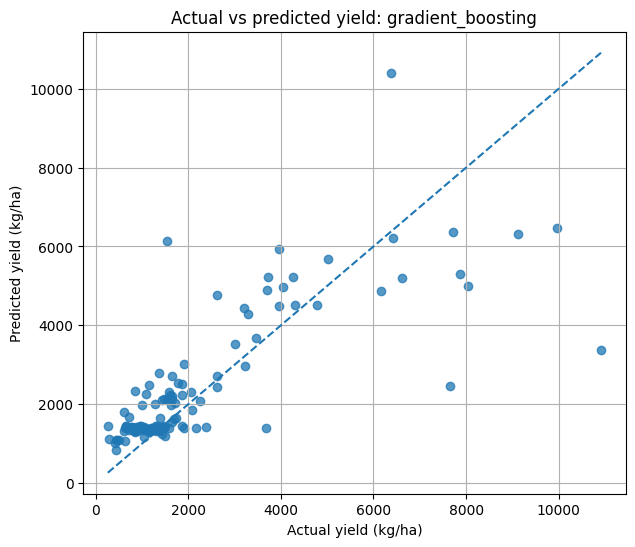

Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\reports\figures\actual_vs_predicted_notebook06.png


In [8]:
best_model_name = holdout_metrics.iloc[0]["model"]
best_preds = predictions.query("model == @best_model_name").copy()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(best_preds[TARGET], best_preds["prediction"], alpha=0.75)
lo = min(best_preds[TARGET].min(), best_preds["prediction"].min())
hi = max(best_preds[TARGET].max(), best_preds["prediction"].max())
ax.plot([lo, hi], [lo, hi], linestyle="--")
ax.set_xlabel("Actual yield (kg/ha)")
ax.set_ylabel("Predicted yield (kg/ha)")
ax.set_title(f"Actual vs predicted yield: {best_model_name}")
save_figure(fig, "figure_02")
plt.show()

fig_path = FIGURES_DIR / "actual_vs_predicted_notebook06.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Saved:", fig_path)

## 6.8 Residual diagnostics

Residuals reveal where the model is systematically too high or too low.

Saved figure: reports\figures\06_baseline_and_machine_learning_models_03_figure_03.png


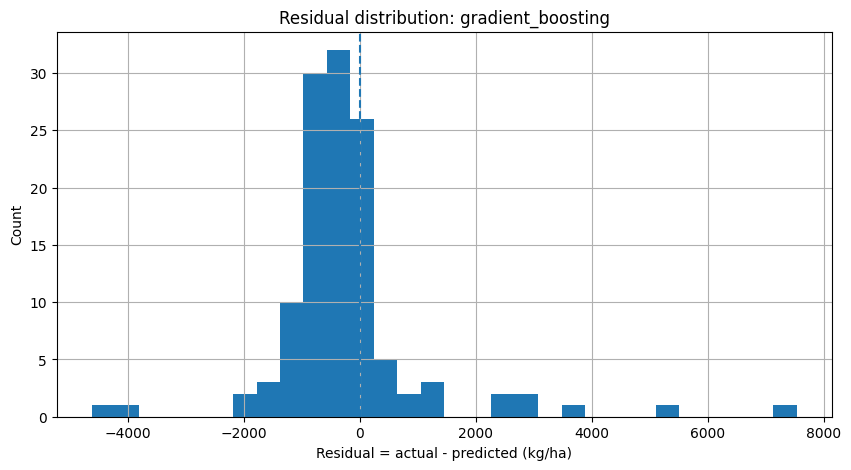

,agroecological_zone,mean_residual,mean_abs_error,n
1,Humid Forest,-673.126497,1499.187412,8
2,Mangrove / Coastal Rainforest,411.646474,1440.127493,5
0,Derived Savannah / Humid Forest Transition,-328.911549,1299.487484,26
4,Southern Guinea Savannah,-210.794940,629.464446,47
5,Sudan Savannah,-44.401746,455.910632,28
3,Sahel / Sudan Savannah,-400.276494,406.424683,8


Saved figure: reports\figures\06_baseline_and_machine_learning_models_04_figure_04.png


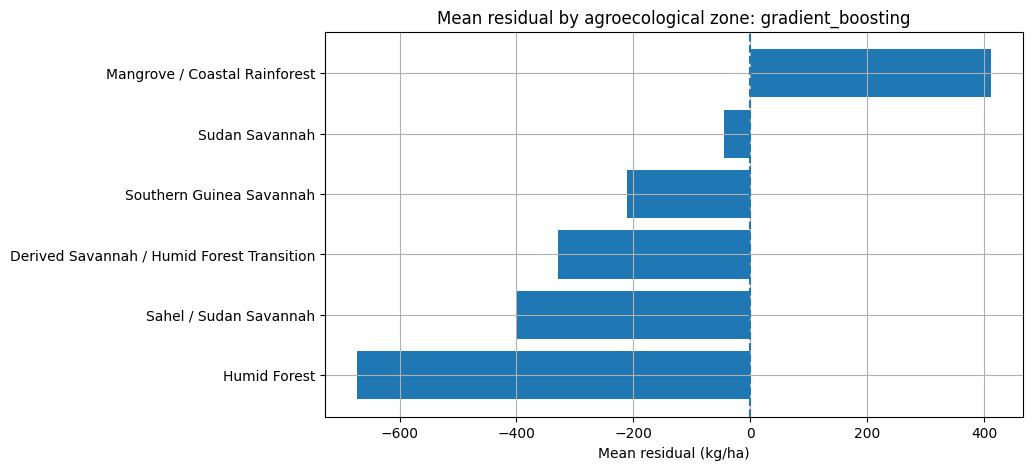

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(best_preds["residual"], bins=30)
ax.axvline(0, linestyle="--")
ax.set_xlabel("Residual = actual - predicted (kg/ha)")
ax.set_ylabel("Count")
ax.set_title(f"Residual distribution: {best_model_name}")
save_figure(fig, "figure_03")
plt.show()

zone_residuals = (
    best_preds.groupby("agroecological_zone", as_index=False)
    .agg(mean_residual=("residual", "mean"), mean_abs_error=("abs_error", "mean"), n=("residual", "size"))
    .sort_values("mean_abs_error", ascending=False)
)
display(zone_residuals)

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = zone_residuals.sort_values("mean_residual")
ax.barh(plot_df["agroecological_zone"], plot_df["mean_residual"])
ax.axvline(0, linestyle="--")
ax.set_xlabel("Mean residual (kg/ha)")
ax.set_title(f"Mean residual by agroecological zone: {best_model_name}")
save_figure(fig, "figure_04")
plt.show()

## 6.9 Crop-wise model performance

A strong project asks where the model works and where it fails.

In [10]:
crop_metrics = []
for (model, crop), g in predictions.groupby(["model", "crop"]):
    if len(g) < 2:
        continue
    crop_metrics.append({
        "model": model,
        "crop": crop,
        "n": len(g),
        "mae": mean_absolute_error(g[TARGET], g["prediction"]),
        "rmse": np.sqrt(mean_squared_error(g[TARGET], g["prediction"])),
        "bias": (g[TARGET] - g["prediction"]).mean(),
    })

crop_metrics = pd.DataFrame(crop_metrics).sort_values(["model", "mae"])
display(crop_metrics.query("model == @best_model_name").sort_values("mae", ascending=False).head(20))

crop_metrics.to_csv(TABLES_DIR / "crop_level_metrics_notebook06.csv", index=False)

,model,crop,n,mae,rmse,bias
48,gradient_boosting,PLANTAIN,3,2122.795423,2236.127270,799.662895
52,gradient_boosting,TOMATO,6,2020.343867,3214.508492,543.014245
38,gradient_boosting,CASSAVA,8,1538.945828,2035.462558,-127.736156
53,gradient_boosting,YAM,7,1160.137251,1279.797682,-328.889388
46,gradient_boosting,OKRO,7,1077.934992,1261.687718,-428.021285
45,gradient_boosting,OIL PALM,4,809.952743,941.157731,-809.952743
39,gradient_boosting,CHILLI PEPPER(SHOMBO),8,779.559236,1847.593106,757.749951
50,gradient_boosting,SOYA BEANS,5,676.562867,701.159088,-676.562867
36,gradient_boosting,BEANS/COWPEA,6,650.174730,664.314279,-650.174730
47,gradient_boosting,ONION,2,635.761663,768.076439,-430.985526
